<a href="https://colab.research.google.com/github/ramanji567/trendpulus_ramanji_task_4-visualization/blob/main/task4_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('trends.202260409.csv')
df.head(20)

,post_id,title,category,score,num_comments,author,collected_at
0,47695012,USB for Software Developers: An introduction t...,technology,219,29,WerWolv,2026-04-09T04:00:57.898220
1,47687273,Git commands I run before reading any code,technology,1868,395,grepsedawk,2026-04-09T04:00:58.415687
2,47689237,US cities are axing Flock Safety surveillance ...,technology,658,385,giuliomagnifico,2026-04-09T04:00:59.610521
3,47674606,Show HN: Unicode Steganography,technology,47,14,PatrickVuscan,2026-04-09T04:01:00.521819
4,47656518,Your File System Is Already A Graph Database,technology,164,71,alxndr,2026-04-09T04:01:00.617421
5,47679121,Project Glasswing: Securing critical software ...,technology,1483,797,Ryan5453,2026-04-09T04:01:01.514452
6,47624572,A database of analog cameras that can be 3D pr...,technology,156,26,thomasjb,2026-04-09T04:01:02.605443
7,47696210,AMD AI director says Claude Code is becoming d...,technology,32,9,Logans_Run,2026-04-09T04:01:04.016159
8,47696336,Show HN: I built a local data lake for AI powe...,technology,8,4,vpfaiz,2026-04-09T04:01:05.038323
9,47675625,Cloudflare targets 2029 for full post-quantum ...,technology,378,112,ilreb,2026-04-09T04:01:06.358586


In [2]:
df["title"]=df["title"].str.strip()
df

,post_id,title,category,score,num_comments,author,collected_at
0,47695012,USB for Software Developers: An introduction t...,technology,219,29,WerWolv,2026-04-09T04:00:57.898220
1,47687273,Git commands I run before reading any code,technology,1868,395,grepsedawk,2026-04-09T04:00:58.415687
2,47689237,US cities are axing Flock Safety surveillance ...,technology,658,385,giuliomagnifico,2026-04-09T04:00:59.610521
3,47674606,Show HN: Unicode Steganography,technology,47,14,PatrickVuscan,2026-04-09T04:01:00.521819
4,47656518,Your File System Is Already A Graph Database,technology,164,71,alxndr,2026-04-09T04:01:00.617421
...,...,...,...,...,...,...,...
94,47690950,Show HN: BAREmail ʕ·ᴥ·ʔ – minimalist Gmail cli...,entertainment,43,40,Virgo_matt,2026-04-09T04:03:31.469581
95,47636579,Show HN: Anos – a hand-written ~100KiB microke...,entertainment,113,31,noone_youknow,2026-04-09T04:03:31.681840
96,47655408,Show HN: I built a tiny LLM to demystify how l...,entertainment,900,134,armanified,2026-04-09T04:03:32.272245
97,47673394,"Show HN: Stop paying for Dropbox/Google Drive,...",entertainment,245,200,Zm44,2026-04-09T04:03:32.508951


In [3]:
import os
os.makedirs("outputs",exist_ok =True)

In [4]:
top_score = df[["score","title"]].sort_values(by="score", ascending=False)
top_score.head(10)

,score,title
1,1868,Git commands I run before reading any code
5,1483,Project Glasswing: Securing critical software ...
15,1324,Issue: Claude Code is unusable for complex eng...
20,1097,Tell HN: Anthropic no longer allowing Claude C...
39,976,The threat is comfortable drift toward not und...
56,955,Show HN: A game where you build a GPU
96,900,Show HN: I built a tiny LLM to demystify how l...
86,776,Show HN: Brutalist Concrete Laptop Stand (2024)
2,658,US cities are axing Flock Safety surveillance ...
24,653,Embarrassingly simple self-distillation improv...


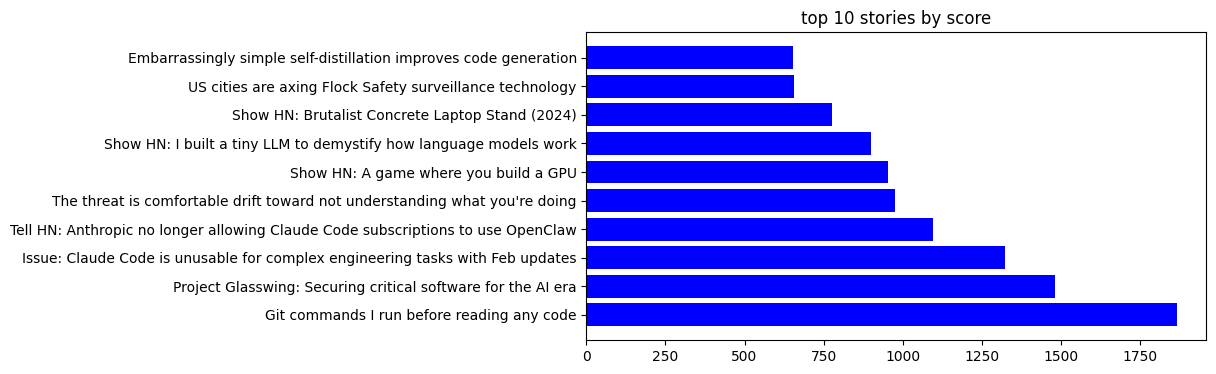

In [10]:
plt.figure(figsize =(8,4))
y_positions = np.arange(len(top_score.head(10))) # Create numerical positions for the bars
plt.barh(y_positions, top_score["score"].head(10), color ="blue") # Use 'score' column for bar width
plt.yticks(y_positions, top_score["title"].head(10))
plt.title("top 10 stories by score") # Use titles for y-tick labels
plt.savefig("outputs/chart1_top_stories.png")
plt.show()

In [6]:
category=df["category"].value_counts()
category

,count
category,
technology,25
entertainment,25
worldnews,24
sports,16
science,9


In [7]:

col =df["category"].unique()
col

array(['technology', 'worldnews', 'sports', 'science', 'entertainment'],
      dtype=object)

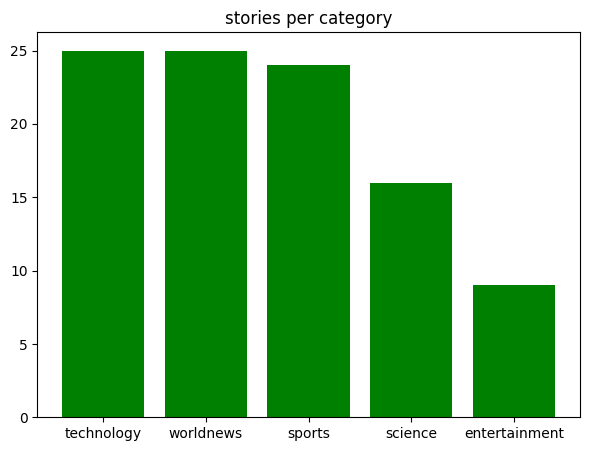

In [12]:
plt.figure(figsize =(7,5))
#y_positions = np.arange(len(category))
x_positions = col # Corrected: closed parenthesis and specified a string label
plt.bar(x_positions,category,color ="green")
plt.title("stories per category")
plt.savefig("outputs/chart2_categories.png")
plt.show()

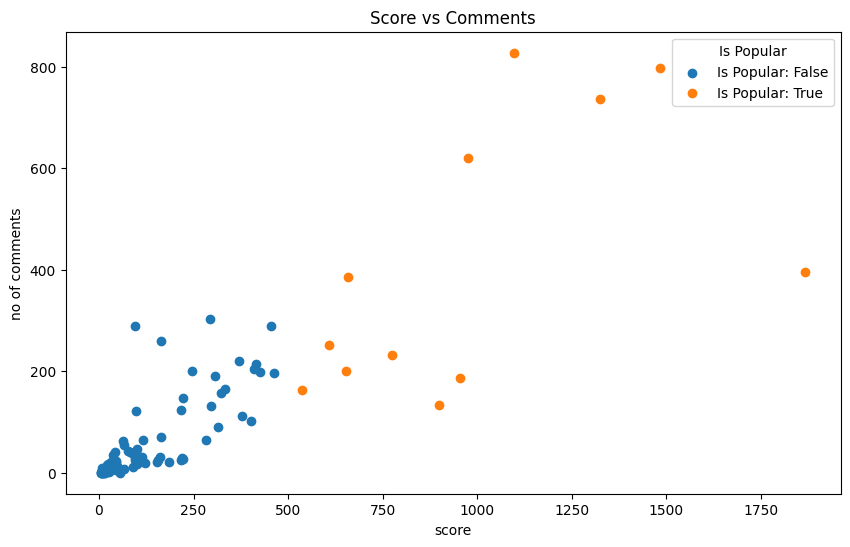

In [9]:
df['is_popular'] = df['score'] > 500 # Example: Define 'is_popular' based on score

plt.figure(figsize=(10,6))

# Get unique values for 'is_popular' to plot separately
unique_is_popular = df['is_popular'].unique()

for val in unique_is_popular:
    subset = df[df['is_popular'] == val]
    plt.scatter(x=subset["score"], y=subset["num_comments"], label=f'Is Popular: {val}')

plt.xlabel("score")
plt.ylabel("no of comments") # Corrected typo 'commnets' to 'comments'
plt.legend(title="Is Popular")
plt.title("Score vs Comments")
plt.savefig("outputs/chart3_scatter.png")
plt.show()

/tmp/ipykernel_9260/123157337.py:24: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


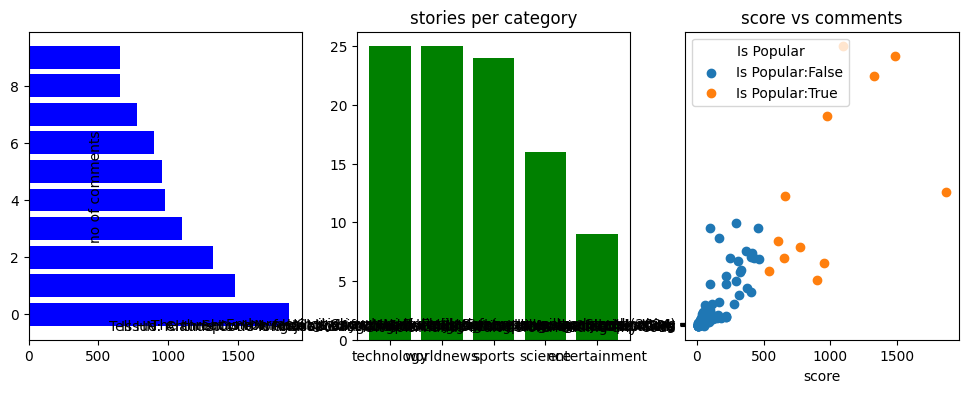

In [20]:
import matplotlib.pyplot as plt
fig,axs = plt.subplots(1,3,figsize=(12,4))
y_positions = np.arange(len(top_score.head(10)))
axs[0].barh(y_positions,top_score["score"].head(10),color="blue")
plt.yticks(y_positions,top_score["title"].head(10))
plt.title("top 10 stories by score")

x_positions = col
axs[1].bar(x_positions,category,color="green")
axs[1].set_title("stories per category")

df['is_popular']= df["score"]>500

unique_is_popular = df["is_popular"].unique()
for val in unique_is_popular:
  subset = df[df["is_popular"]==val]
  axs[2].scatter(x=subset["score"],y=subset["num_comments"],label =f'Is Popular:{val}')
plt.xlabel("score")
plt.ylabel("no of comments")
plt.legend(title = "Is Popular")
axs[2].set_title("score vs comments")

plt.savefig("outputs/dashboard.png")
plt.tight_layout()
plt.show()